
# Introducción interactiva a CNN (MNIST + CIFAR-10)

Este notebook contiene **dos mini-labs** con ejemplos **interactivos** para entender y entrenar CNNs:

1. **MNIST (dígitos)**: CNN sencilla + *playground* de hiperparámetros.
2. **CIFAR-10 (imágenes a color)**: CNN algo más profunda + *data augmentation* opcional.

> Si los widgets no se ven: instala/activa `ipywidgets` (depende de tu JupyterLab/Notebook).



## 0) Setup
Instala dependencias si hace falta y carga librerías.


In [1]:

# Si necesitas instalar widgets (descomenta):
# !pip -q install ipywidgets

import os, math, numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Widgets (si están disponibles)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_OK = True
except Exception as e:
    WIDGETS_OK = False
    print("⚠️ ipywidgets no disponible. Puedes instalarlo con: pip install ipywidgets")
    print("Error:", e)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Reproducibilidad básica
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Mejoras opcionales (si hay GPU)
try:
    tf.config.optimizer.set_jit(True)  # XLA (puede ayudar)
except Exception:
    pass


2026-02-20 12:57:36.310365: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 12:57:36.425504: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-20 12:57:36.425523: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-02-20 12:57:36.453482: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-20 12:57:36.959778: W tensorflow/stream_executor/platform/de

TensorFlow: 2.10.0
GPUs: []


2026-02-20 12:57:37.832640: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-20 12:57:37.833078: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-20 12:57:37.833164: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-02-20 12:57:37.833245: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-02-20 12:57:37.833314: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co


## 1) Utilidades (plots + modelo)

Funciones de ayuda para visualizar datos, construir modelos CNN y entrenar.


In [2]:

def show_images_grid(x, y=None, n=16, title=None, cmap=None):
    # Muestra una cuadrícula de imágenes
    n = min(n, len(x))
    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(1.8*cols, 1.8*rows))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        img = x[i]
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img[..., 0]
        plt.imshow(img, cmap=cmap)
        plt.axis("off")
        if y is not None:
            plt.title(str(y[i]), fontsize=10)
    if title:
        plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_history(history, title=None):
    # Plots de loss/accuracy para un History de Keras
    if history is None:
        return
    h = history.history
    plt.figure(figsize=(6,4))
    if "loss" in h: plt.plot(h["loss"], label="train_loss")
    if "val_loss" in h: plt.plot(h["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    if title: plt.title(title)
    plt.legend()
    plt.show()

    # Accuracy (si existe)
    acc_key = None
    for k in ["accuracy", "acc", "sparse_categorical_accuracy"]:
        if k in h:
            acc_key = k
            break
    val_acc_key = None
    for k in ["val_accuracy", "val_acc", "val_sparse_categorical_accuracy"]:
        if k in h:
            val_acc_key = k
            break

    if acc_key is not None:
        plt.figure(figsize=(6,4))
        plt.plot(h[acc_key], label="train_acc")
        if val_acc_key is not None:
            plt.plot(h[val_acc_key], label="val_acc")
        plt.xlabel("epoch")
        plt.ylabel("accuracy")
        if title: plt.title(title)
        plt.legend()
        plt.show()


def compile_model(model, optimizer_name="adam", lr=1e-3):
    if optimizer_name.lower() == "adam":
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name.lower() == "sgd":
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer_name.lower() == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        raise ValueError("optimizer_name debe ser: adam | sgd | rmsprop")

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_simple_cnn(
    input_shape,
    num_classes,
    conv_blocks=2,
    base_filters=32,
    kernel_size=3,
    dense_units=128,
    dropout=0.25,
    batchnorm=True,
):
    # CNN clásica: (Conv->(BN)->ReLU->MaxPool)-> ... -> Dense
    inputs = keras.Input(shape=input_shape)
    x = inputs

    for b in range(conv_blocks):
        filters = base_filters * (2**b)
        x = layers.Conv2D(filters, kernel_size, padding="same")(x)
        if batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv2D(filters, kernel_size, padding="same")(x)
        if batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.MaxPooling2D()(x)
        if dropout and dropout > 0:
            x = layers.Dropout(dropout)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(dense_units)(x)
    x = layers.ReLU()(x)
    if dropout and dropout > 0:
        x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)


def quick_train(
    model,
    x_train, y_train,
    x_val, y_val,
    epochs=3,
    batch_size=128,
    verbose=1,
):
    cb = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
    ]
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=cb,
    )
    return history


def show_predictions(model, x, y=None, class_names=None, n=12, title=None):
    # Muestra n predicciones (imagen + etiqueta real + pred)
    n = min(n, len(x))
    preds = model.predict(x[:n], verbose=0)
    yhat = np.argmax(preds, axis=1)

    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(2.2*cols, 2.2*rows))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        img = x[i]
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img[..., 0]
        plt.imshow(img, cmap="gray" if img.ndim==2 else None)
        plt.axis("off")

        pred_name = class_names[yhat[i]] if class_names is not None else str(yhat[i])
        if y is not None:
            true_name = class_names[y[i]] if class_names is not None else str(y[i])
            plt.title(f"T:{true_name}\nP:{pred_name}", fontsize=9)
        else:
            plt.title(f"P:{pred_name}", fontsize=9)

    if title:
        plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()



# Parte A — MNIST (28×28, 1 canal)

Objetivo: entrenar una CNN sencilla y tocar hiperparámetros de forma interactiva.

- Datos: MNIST (dígitos 0–9)
- Input: (28, 28, 1)
- Salida: 10 clases


Train: (50000, 28, 28, 1) (50000,)
Val  : (10000, 28, 28, 1) (10000,)
Test : (10000, 28, 28, 1) (10000,)


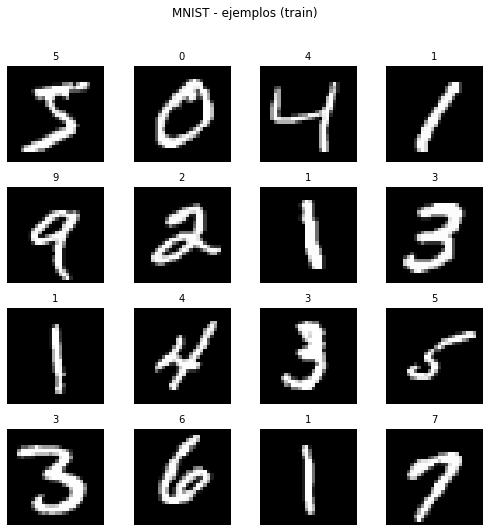

In [3]:

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalización + canal
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)  # (N, 28, 28, 1)
x_test  = np.expand_dims(x_test, -1)

# Validación
val_size = 10000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr , y_tr  = x_train[:-val_size], y_train[:-val_size]

print("Train:", x_tr.shape, y_tr.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test.shape, y_test.shape)

show_images_grid(x_tr, y_tr, n=16, title="MNIST - ejemplos (train)", cmap="gray")



## A1) Playground interactivo (MNIST)

Ajusta parámetros y pulsa **Entrenar**. Por defecto entrena rápido (subconjunto + pocas épocas).


In [4]:

# Para hacerlo ligero, por defecto entrenamos con subset
def get_subset(x, y, n):
    n = min(n, len(x))
    return x[:n], y[:n]

MNIST_CLASS_NAMES = [str(i) for i in range(10)]

def run_mnist_experiment(
    conv_blocks=2,
    base_filters=32,
    kernel_size=3,
    dense_units=128,
    dropout=0.25,
    batchnorm=True,
    optimizer="adam",
    lr=1e-3,
    epochs=3,
    batch_size=128,
    train_subset=20000,
    val_subset=5000,
):
    # Subsets para rapidez (puedes poner train_subset=len(x_tr) si quieres)
    xtr, ytr = get_subset(x_tr, y_tr, train_subset)
    xva, yva = get_subset(x_val, y_val, val_subset)

    model = build_simple_cnn(
        input_shape=xtr.shape[1:],
        num_classes=10,
        conv_blocks=conv_blocks,
        base_filters=base_filters,
        kernel_size=kernel_size,
        dense_units=dense_units,
        dropout=dropout,
        batchnorm=batchnorm,
    )
    compile_model(model, optimizer_name=optimizer, lr=lr)

    history = quick_train(
        model,
        xtr, ytr,
        xva, yva,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )

    # Evaluación
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"✅ Test acc: {test_acc:.4f} | Test loss: {test_loss:.4f}")
    print(model.count_params(), "params")

    plot_history(history, title="MNIST - training curves")
    show_predictions(model, x_test, y_test, class_names=MNIST_CLASS_NAMES, n=16, title="MNIST - predicciones (test)")

    return model, history


if not WIDGETS_OK:
    print("Widgets no disponibles -> ejecuta run_mnist_experiment(...) a mano.")
else:
    # Widgets
    w_conv_blocks  = widgets.IntSlider(value=2, min=1, max=3, step=1, description="conv_blocks")
    w_base_filters = widgets.Dropdown(options=[16, 32, 48, 64], value=32, description="base_filters")
    w_kernel       = widgets.Dropdown(options=[3, 5], value=3, description="kernel")
    w_dense        = widgets.Dropdown(options=[64, 128, 256], value=128, description="dense_units")
    w_dropout      = widgets.FloatSlider(value=0.25, min=0.0, max=0.6, step=0.05, description="dropout")
    w_bn           = widgets.Checkbox(value=True, description="batchnorm")
    w_opt          = widgets.Dropdown(options=["adam", "sgd", "rmsprop"], value="adam", description="optimizer")
    w_lr           = widgets.FloatLogSlider(value=1e-3, base=10, min=-5, max=-1, step=0.2, description="lr")
    w_epochs       = widgets.IntSlider(value=3, min=1, max=10, step=1, description="epochs")
    w_bs           = widgets.Dropdown(options=[64, 128, 256], value=128, description="batch_size")
    w_trsub        = widgets.Dropdown(options=[5000, 10000, 20000, 40000, len(x_tr)], value=20000, description="train_n")
    w_valsub       = widgets.Dropdown(options=[2000, 5000, 10000], value=5000, description="val_n")

    btn = widgets.Button(description="🚀 Entrenar (MNIST)", button_style="success")
    out = widgets.Output()

    def on_click(_):
        with out:
            clear_output(wait=True)
            run_mnist_experiment(
                conv_blocks=w_conv_blocks.value,
                base_filters=w_base_filters.value,
                kernel_size=w_kernel.value,
                dense_units=w_dense.value,
                dropout=w_dropout.value,
                batchnorm=w_bn.value,
                optimizer=w_opt.value,
                lr=w_lr.value,
                epochs=w_epochs.value,
                batch_size=w_bs.value,
                train_subset=w_trsub.value,
                val_subset=w_valsub.value,
            )

    btn.on_click(on_click)

    display(widgets.VBox([
        widgets.HTML("<b>MNIST CNN Playground</b>"),
        widgets.HBox([w_conv_blocks, w_base_filters, w_kernel]),
        widgets.HBox([w_dense, w_dropout, w_bn]),
        widgets.HBox([w_opt, w_lr, w_epochs, w_bs]),
        widgets.HBox([w_trsub, w_valsub]),
        btn,
        out
    ]))



# Parte B — CIFAR-10 (32×32×3)

Objetivo: ver cómo cambia el entrenamiento con imágenes a color y clases más difíciles.
Añadimos **data augmentation** opcional para mejorar generalización.


In [ ]:

from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Validación
val_size = 5000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr , y_tr  = x_train[:-val_size], y_train[:-val_size]

CIFAR10_CLASS_NAMES = [
    "airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"
]

print("Train:", x_tr.shape, y_tr.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test.shape, y_test.shape)

show_images_grid(x_tr, [CIFAR10_CLASS_NAMES[i] for i in y_tr], n=16, title="CIFAR-10 - ejemplos (train)")



## B1) Playground interactivo (CIFAR-10)

Incluye opción de **data augmentation** (flip/rot/zoom). CIFAR es más difícil: no esperes >90% con una CNN pequeña y pocas épocas.


In [ ]:

def build_cifar_cnn(
    input_shape,
    num_classes=10,
    conv_blocks=3,
    base_filters=32,
    kernel_size=3,
    dense_units=256,
    dropout=0.3,
    batchnorm=True,
    use_augmentation=True,
):
    inputs = keras.Input(shape=input_shape)

    x = inputs
    if use_augmentation:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.1),
        ])
        x = aug(x)

    # Feature extractor
    for b in range(conv_blocks):
        filters = base_filters * (2**b)

        x = layers.Conv2D(filters, kernel_size, padding="same")(x)
        if batchnorm: x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv2D(filters, kernel_size, padding="same")(x)
        if batchnorm: x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.MaxPooling2D()(x)
        if dropout and dropout > 0:
            x = layers.Dropout(dropout)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units)(x)
    x = layers.ReLU()(x)
    if dropout and dropout > 0:
        x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)


def run_cifar_experiment(
    conv_blocks=3,
    base_filters=32,
    kernel_size=3,
    dense_units=256,
    dropout=0.3,
    batchnorm=True,
    use_augmentation=True,
    optimizer="adam",
    lr=1e-3,
    epochs=5,
    batch_size=128,
    train_subset=30000,
    val_subset=5000,
):
    # Subsets (para rapidez)
    xtr, ytr = x_tr[:min(train_subset, len(x_tr))], y_tr[:min(train_subset, len(y_tr))]
    xva, yva = x_val[:min(val_subset, len(x_val))], y_val[:min(val_subset, len(y_val))]

    model = build_cifar_cnn(
        input_shape=xtr.shape[1:],
        conv_blocks=conv_blocks,
        base_filters=base_filters,
        kernel_size=kernel_size,
        dense_units=dense_units,
        dropout=dropout,
        batchnorm=batchnorm,
        use_augmentation=use_augmentation,
    )
    compile_model(model, optimizer_name=optimizer, lr=lr)

    # Callbacks
    cb = [
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=0),
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
    ]

    history = model.fit(
        xtr, ytr,
        validation_data=(xva, yva),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=cb,
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"✅ Test acc: {test_acc:.4f} | Test loss: {test_loss:.4f}")
    print(model.count_params(), "params")

    plot_history(history, title="CIFAR-10 - training curves")
    show_predictions(model, x_test, y_test, class_names=CIFAR10_CLASS_NAMES, n=16, title="CIFAR-10 - predicciones (test)")
    return model, history


if not WIDGETS_OK:
    print("Widgets no disponibles -> ejecuta run_cifar_experiment(...) a mano.")
else:
    w_conv_blocks  = widgets.IntSlider(value=3, min=2, max=4, step=1, description="conv_blocks")
    w_base_filters = widgets.Dropdown(options=[16, 32, 48, 64], value=32, description="base_filters")
    w_kernel       = widgets.Dropdown(options=[3, 5], value=3, description="kernel")
    w_dense        = widgets.Dropdown(options=[128, 256, 512], value=256, description="dense_units")
    w_dropout      = widgets.FloatSlider(value=0.30, min=0.0, max=0.6, step=0.05, description="dropout")
    w_bn           = widgets.Checkbox(value=True, description="batchnorm")
    w_aug          = widgets.Checkbox(value=True, description="augmentation")
    w_opt          = widgets.Dropdown(options=["adam", "sgd", "rmsprop"], value="adam", description="optimizer")
    w_lr           = widgets.FloatLogSlider(value=1e-3, base=10, min=-5, max=-1, step=0.2, description="lr")
    w_epochs       = widgets.IntSlider(value=5, min=1, max=20, step=1, description="epochs")
    w_bs           = widgets.Dropdown(options=[64, 128, 256], value=128, description="batch_size")
    w_trsub        = widgets.Dropdown(options=[5000, 10000, 20000, 30000, 45000, len(x_tr)], value=30000, description="train_n")
    w_valsub       = widgets.Dropdown(options=[2000, 5000], value=5000, description="val_n")

    btn = widgets.Button(description="🚀 Entrenar (CIFAR-10)", button_style="success")
    out = widgets.Output()

    def on_click(_):
        with out:
            clear_output(wait=True)
            run_cifar_experiment(
                conv_blocks=w_conv_blocks.value,
                base_filters=w_base_filters.value,
                kernel_size=w_kernel.value,
                dense_units=w_dense.value,
                dropout=w_dropout.value,
                batchnorm=w_bn.value,
                use_augmentation=w_aug.value,
                optimizer=w_opt.value,
                lr=w_lr.value,
                epochs=w_epochs.value,
                batch_size=w_bs.value,
                train_subset=w_trsub.value,
                val_subset=w_valsub.value,
            )

    btn.on_click(on_click)

    display(widgets.VBox([
        widgets.HTML("<b>CIFAR-10 CNN Playground</b>"),
        widgets.HBox([w_conv_blocks, w_base_filters, w_kernel]),
        widgets.HBox([w_dense, w_dropout, w_bn, w_aug]),
        widgets.HBox([w_opt, w_lr, w_epochs, w_bs]),
        widgets.HBox([w_trsub, w_valsub]),
        btn,
        out
    ]))



## Ideas para extender (opcional)

- Añadir **Transfer Learning** (p.ej., `MobileNetV2` / `EfficientNet`) para CIFAR-10.
- Visualizar **mapas de activación** (feature maps) y **filtros**.
- Probar regularización: **L2**, **Dropout**, **Label smoothing**.
- Usar `tf.data` para *pipelines* más rápidos.
